# 02 – Technician Dispatch Optimization
## Business Context
A ServiceTitan contractor has 10 technicians and receives 40-80 service calls daily across a metro area.
Dispatchers must assign and sequence jobs in real time while dealing with:
- New calls arriving throughout the day
- Jobs running over/under estimated duration
- Traffic and travel time
- Technician skill requirements (not every tech does every job type)
- Customer time window preferences (morning vs. afternoon)

Poor dispatch = overtime, unhappy customers, wasted drive time.

## ML's Role
Pure optimization handles the assignment (Greedy/OR-Tools). ML provides **learned inputs**:
- Job duration prediction (most impactful)
- Travel time modeling (time-of-day aware)
- First-time fix probability

This notebook focuses on the **job duration prediction model** — the single most impactful
ML component in the dispatch stack.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Job History Dataset ───────────────────────────────────────────
# Each row is a completed job with known ground-truth duration

N = 8000  # historical jobs

job_types = ['ac_repair', 'ac_install', 'furnace_repair', 'furnace_install',
             'drain_clear', 'water_heater', 'electrical_panel', 'tune_up']

# Base durations (minutes) per job type — realistic HVAC/plumbing ranges
base_duration = {
    'ac_repair': 90, 'ac_install': 240, 'furnace_repair': 75,
    'furnace_install': 210, 'drain_clear': 45, 'water_heater': 120,
    'electrical_panel': 180, 'tune_up': 60
}

job_type   = np.random.choice(job_types, size=N)
base_mins  = np.array([base_duration[j] for j in job_type])

equipment_age = np.random.uniform(1, 20, size=N)          # years
property_sqft = np.random.normal(1800, 600, size=N).clip(600, 5000)
new_customer  = np.random.binomial(1, 0.35, size=N)       # new = longer (walkthroughs)
tech_id       = np.random.randint(0, 15, size=N)           # 15 technicians
# Tech skill factor: some techs are faster (0.85) or slower (1.15)
tech_speed    = 1.0 + np.random.normal(0, 0.1, size=15)
tech_factor   = tech_speed[tech_id]

time_of_day   = np.random.choice(['morning','midday','afternoon','evening'], size=N)
tod_factor    = {'morning': 1.0, 'midday': 1.05, 'afternoon': 1.1, 'evening': 1.15}
tod_mult      = np.array([tod_factor[t] for t in time_of_day])

day_of_week   = np.random.choice(['Mon','Tue','Wed','Thu','Fri','Sat'], size=N)
weekend_mult  = np.where(day_of_week == 'Sat', 1.1, 1.0)

# --- Actual duration: base × technician speed × context factors + noise ---
actual_duration = (
    base_mins
    * tech_factor
    * tod_mult
    * weekend_mult
    * (1 + 0.03 * (equipment_age - 10))  # older equipment takes longer
    * (1 + 0.0001 * (property_sqft - 1800))
    * (1 + 0.15 * new_customer)
    + np.random.lognormal(0, 0.2, size=N) * 10  # stochastic noise (log-normal, right-skewed)
).clip(15, 600)

jobs_df = pd.DataFrame({
    'job_type': job_type,
    'equipment_age_yrs': equipment_age.round(1),
    'property_sqft': property_sqft.round(0).astype(int),
    'new_customer': new_customer,
    'tech_id': tech_id,
    'time_of_day': time_of_day,
    'day_of_week': day_of_week,
    'actual_duration_min': actual_duration.round(1)
})

print(f"Dataset: {jobs_df.shape}")
print(f"Duration stats (minutes):")
print(jobs_df['actual_duration_min'].describe().round(1))


Dataset: (8000, 8)
Duration stats (minutes):
count    8000.0
mean      152.4
std        84.1
min        38.0
25%        82.2
50%       124.4
75%       216.1
max       484.3
Name: actual_duration_min, dtype: float64


## Duration Distribution
Job durations are **right-skewed** (log-normal). A small number of jobs run very long.
This matters for model choice and for the optimizer — a P90 estimate is safer to
schedule than a mean estimate.


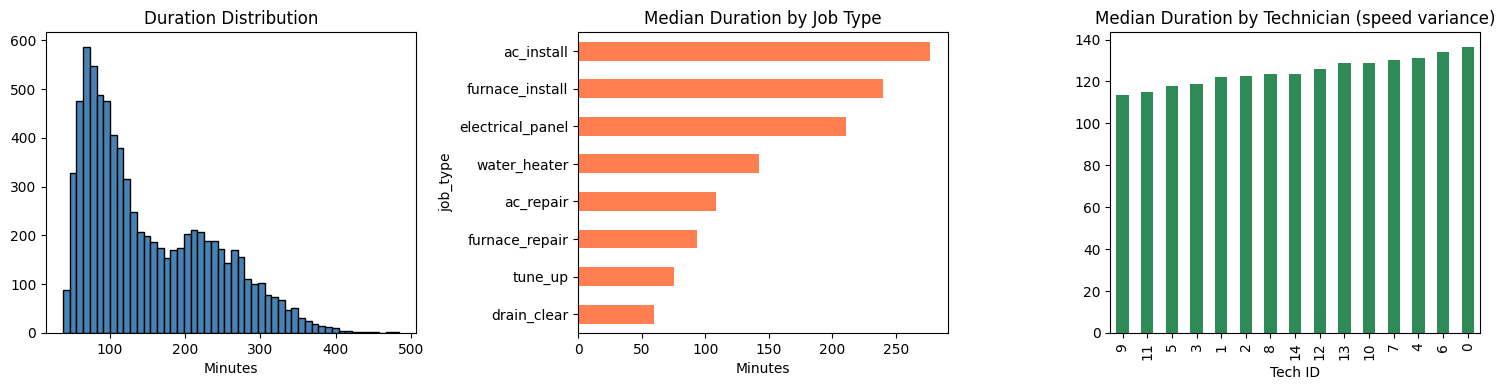

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Overall distribution
axes[0].hist(jobs_df['actual_duration_min'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Duration Distribution'); axes[0].set_xlabel('Minutes')

# By job type (median)
jobs_df.groupby('job_type')['actual_duration_min'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Median Duration by Job Type'); axes[1].set_xlabel('Minutes')

# Technician variance — some techs are consistently faster
tech_medians = jobs_df.groupby('tech_id')['actual_duration_min'].median().sort_values()
tech_medians.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Median Duration by Technician (speed variance)')
axes[2].set_xlabel('Tech ID')

plt.tight_layout()
plt.savefig('dispatch_eda.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
# ─── Model Training ───────────────────────────────────────────────────────────
features = ['job_type', 'equipment_age_yrs', 'property_sqft',
            'new_customer', 'tech_id', 'time_of_day', 'day_of_week']
target = 'actual_duration_min'

X = jobs_df[features]
y = jobs_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: one-hot encode categoricals, pass numerics through
categorical_features = ['job_type', 'time_of_day', 'day_of_week']
numeric_features = ['equipment_age_yrs', 'property_sqft', 'new_customer', 'tech_id']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# Gradient Boosted Trees — best for tabular regression with mixed types
gbm = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                         learning_rate=0.05, random_state=42))
])
gbm.fit(X_train, y_train)
gbm_preds = gbm.predict(X_test)

mae  = mean_absolute_error(y_test, gbm_preds)
rmse = np.sqrt(mean_squared_error(y_test, gbm_preds))
print(f"GBM  MAE: {mae:.1f} min  |  RMSE: {rmse:.1f} min")
print(f"Mean actual duration: {y_test.mean():.1f} min")
print(f"MAE as % of mean: {mae/y_test.mean()*100:.1f}%")


GBM  MAE: 6.0 min  |  RMSE: 9.2 min
Mean actual duration: 155.1 min
MAE as % of mean: 3.9%


## Quantile Regression: Building Uncertainty into the Schedule
The **optimizer needs a conservative (P90) estimate**, not just the mean.
If we always schedule based on the mean, ~50% of jobs will run over — cascading
delays all afternoon.

We train quantile regressors for P10, P50, and P90 of the duration distribution.


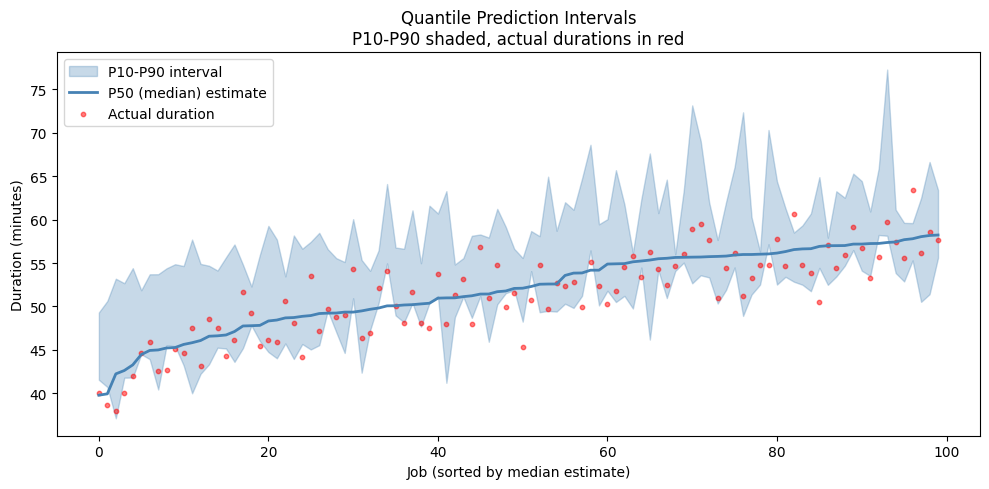

P10-P90 interval coverage: 78.6%  (target: ~80%)


In [5]:
from sklearn.ensemble import GradientBoostingRegressor

def train_quantile(q, X_tr, y_tr, preprocessor):
    """Train a quantile GBM for a given quantile q (0-1)."""
    Xp = preprocessor.transform(X_tr)
    m = GradientBoostingRegressor(loss='quantile', alpha=q,
                                   n_estimators=100, max_depth=4,
                                   learning_rate=0.08, random_state=42)
    m.fit(Xp, y_tr)
    return m

# Fit preprocessor on training data
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

model_p10 = train_quantile(0.10, X_train, y_train, preprocessor)
model_p50 = train_quantile(0.50, X_train, y_train, preprocessor)
model_p90 = train_quantile(0.90, X_train, y_train, preprocessor)

preds_p10 = model_p10.predict(X_test_t)
preds_p50 = model_p50.predict(X_test_t)
preds_p90 = model_p90.predict(X_test_t)

# ─── Visualize prediction intervals ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
idx = np.argsort(preds_p50)[:100]  # sort by median for clean display
ax.fill_between(range(100), preds_p10[idx], preds_p90[idx],
                alpha=0.3, label='P10-P90 interval', color='steelblue')
ax.plot(preds_p50[idx], label='P50 (median) estimate', color='steelblue', lw=2)
ax.scatter(range(100), y_test.values[idx], s=10, alpha=0.5,
           color='red', label='Actual duration')
ax.set_title('Quantile Prediction Intervals\nP10-P90 shaded, actual durations in red')
ax.set_xlabel('Job (sorted by median estimate)')
ax.set_ylabel('Duration (minutes)')
ax.legend()
plt.tight_layout()
plt.savefig('dispatch_quantile.png', dpi=100, bbox_inches='tight')
plt.show()

# Coverage check: actual should fall within P10-P90 about 80% of the time
coverage = ((y_test.values >= preds_p10) & (y_test.values <= preds_p90)).mean()
print(f"P10-P90 interval coverage: {coverage:.1%}  (target: ~80%)")


## Greedy Dispatch Simulation
To show how the duration model feeds the optimizer, we simulate a simple greedy
dispatch: assign each incoming job to the technician who can complete it earliest.


In [6]:
from collections import defaultdict

def simulate_dispatch(n_jobs=30, n_techs=5):
    """
    Greedy dispatch: assign job to tech with earliest available time.
    Uses P90 duration estimates to build in schedule buffer.
    Returns per-tech schedule and utilization.
    """
    rng = np.random.default_rng(99)

    # Generate jobs for one day
    job_types_today = rng.choice(job_types, size=n_jobs)
    new_cust        = rng.binomial(1, 0.35, size=n_jobs)
    eq_age          = rng.uniform(1, 20, size=n_jobs)
    sqft            = rng.normal(1800, 500, size=n_jobs).clip(600, 5000)
    # All jobs are this morning → time_of_day = morning
    job_df_today = pd.DataFrame({
        'job_type': job_types_today,
        'equipment_age_yrs': eq_age.round(1),
        'property_sqft': sqft.round(0),
        'new_customer': new_cust,
        'tech_id': 0,  # placeholder; will vary below
        'time_of_day': 'morning',
        'day_of_week': 'Mon'
    })

    # Tech state: when each tech becomes free (minutes since 8am)
    tech_free_at = [0.0] * n_techs
    schedule = defaultdict(list)

    for i in range(n_jobs):
        # Estimate duration for this job with each tech (use their ID)
        best_tech = None
        best_start = float('inf')

        for t in range(n_techs):
            job_df_today.at[i, 'tech_id'] = t
            sample = job_df_today.iloc[[i]]
            sample_t = preprocessor.transform(sample)
            p90_duration = model_p90.predict(sample_t)[0]
            p50_duration = model_p50.predict(sample_t)[0]

            start_time = tech_free_at[t]
            # Travel time: simple proxy (5-25 min random for this demo)
            travel_time = rng.uniform(5, 25)
            finish_time = start_time + travel_time + p90_duration

            if start_time < best_start:
                best_start   = start_time
                best_tech    = t
                best_p90     = p90_duration
                best_p50     = p50_duration
                best_travel  = travel_time

        tech_free_at[best_tech] = best_start + best_travel + best_p90
        schedule[best_tech].append({
            'job': i, 'type': job_types_today[i],
            'start': best_start, 'p50_est': best_p50, 'p90_est': best_p90
        })

    # Print utilization
    print("=== End-of-Day Tech Schedule Summary ===")
    for t in range(n_techs):
        end_time = tech_free_at[t]
        hrs = end_time / 60
        n_jobs_assigned = len(schedule[t])
        print(f"Tech {t}: {n_jobs_assigned} jobs | Done at {8 + hrs:.1f}h | "
              f"{'OVERTIME' if hrs > 9 else 'On time'}")

    return schedule

sched = simulate_dispatch(n_jobs=40, n_techs=6)


=== End-of-Day Tech Schedule Summary ===
Tech 0: 7 jobs | Done at 22.2h | OVERTIME
Tech 1: 8 jobs | Done at 24.1h | OVERTIME
Tech 2: 8 jobs | Done at 24.9h | OVERTIME
Tech 3: 6 jobs | Done at 23.3h | OVERTIME
Tech 4: 4 jobs | Done at 24.5h | OVERTIME
Tech 5: 7 jobs | Done at 25.0h | OVERTIME


## Key Takeaways for Interview

1. **ML's role is providing accurate inputs to the optimizer** — not doing the optimization itself
2. **Use P90 duration estimates** for scheduling; P50 means half your afternoon will cascade
3. **Technician ID is a valid feature** — some are genuinely faster; this isn't bias, it's personalization
4. **For real-time re-dispatch**: use insertion heuristics (where cheapest to insert new job?)
5. **Full re-optimization** (OR-Tools VRPTW) runs overnight for next-day planning
6. **The feedback loop**: actual duration vs. estimate updates the model on every completed job


---
## Dispatch Pro: The Full System

### What Dispatch Pro Actually Does

Dispatch Pro is ServiceTitan's ML-assisted technician assignment product. It surfaces a
ranked list of technicians for each job with a predicted score combining several signals.
The dispatcher can override, but the ML recommendation dramatically reduces cognitive load
during peak hours when 10+ jobs may be queued simultaneously.

**The five ML signals Dispatch Pro combines:**

| Signal | Model Type | Why it Matters |
|---|---|---|
| Job duration estimate | GBM quantile regression | Core schedule feasibility |
| Travel time (time-of-day aware) | GBM or lookup table on historical GPS data | Drive time is 20-40% of a tech's day |
| First-time fix probability | Logistic regression / GBM classifier | A callback job is 2x the cost |
| Tech-job skill match score | Rule-based + historical success rate | Hard constraint: wrong skills = failed job |
| Tech workload balance | Rule-based | Avoid overloading one tech while others idle |

**The optimization objective** (simplified):
```
minimize:  sum( travel_time + p90_duration ) * job_priority_weight
subject to:
    skill_match(tech, job) = True          # hard constraint
    tech_available_by(job.time_window)     # hard constraint
    total_day_load(tech) <= shift_end      # soft constraint (overtime penalty)
```

### Where ML ends and optimization begins

- **ML layer**: Produces *inputs* — duration estimates, travel time corrections, fix probability
- **Optimization layer**: Takes those inputs and solves the assignment (OR-Tools VRPTW, greedy, or Hungarian algorithm)
- **Feedback layer**: Actual durations flow back to retrain ML models on every completed job

The optimization layer is deterministic given ML inputs — you can A/B test models
independently of the optimizer, which is how ServiceTitan ships model updates safely
across 12K tenants.


---
## NetworkX: Graph-Based Dispatch Formulation

### Why Model Dispatch as a Graph?

The technician-job assignment problem is a **minimum weight bipartite matching** problem:
- Left nodes = available technicians
- Right nodes = pending jobs  
- Edge weight = cost of assigning that tech to that job (travel + duration + overtime risk)

**Why this matters for interviews:** NetworkX lets you express this naturally and shows you
understand the graph structure underlying dispatch. The Hungarian algorithm
(`scipy.optimize.linear_sum_assignment`) solves small instances optimally in O(n^3);
for large instances, ServiceTitan likely uses OR-Tools with the VRP formulation.

### Three NetworkX use cases for dispatch:
1. **Bipartite matching** — optimal assignment of N techs to N jobs
2. **Geographic routing graph** — job locations as nodes, drive times as edge weights, shortest route per tech
3. **Skill/constraint graph** — which techs are eligible for which jobs (prune before optimizer)


In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Use Case 1: Bipartite Tech-Job Matching ---
# Build a bipartite graph where edge weight = assignment cost.
# Then find the minimum weight perfect matching.

N_TECHS = 6
N_JOBS  = 6

rng = np.random.default_rng(7)

travel_times = rng.uniform(5, 45, size=(N_TECHS, N_JOBS))

job_types_sample = ['ac_repair', 'drain_clear', 'water_heater',
                    'furnace_repair', 'tune_up', 'electrical_panel']
base_p90 = {
    'ac_repair': 120, 'drain_clear': 60, 'water_heater': 150,
    'furnace_repair': 100, 'tune_up': 75, 'electrical_panel': 220
}
job_p90_durations = np.array([base_p90[j] for j in job_types_sample])

# Cost matrix: travel + P90 duration
cost_matrix = travel_times + job_p90_durations[np.newaxis, :]

# Skill constraint: electrical_panel requires certification (only techs 0, 2, 4)
ELECTRICAL_JOB_IDX = 5
ineligible_techs = [1, 3, 5]
cost_matrix[ineligible_techs, ELECTRICAL_JOB_IDX] = 9999

print("Cost matrix (travel + P90 duration, minutes):")
print(f"{'':>12}", end="")
for j in job_types_sample:
    print(f"{j:>16}", end="")
print()
for t in range(N_TECHS):
    cert = " [elec cert]" if t not in ineligible_techs else ""
    print(f"Tech {t}{cert:>11}", end="")
    for j in range(N_JOBS):
        c = cost_matrix[t, j]
        print(f"{'INF':>16}" if c > 9000 else f"{c:>16.0f}", end="")
    print()


Cost matrix (travel + P90 duration, minutes):
                   ac_repair     drain_clear    water_heater  furnace_repair         tune_upelectrical_panel
Tech 0 [elec cert]             150             101             186             114              92             260
Tech 1                        125              98             187             124              92             INF
Tech 2 [elec cert]             135              83             175             127             120             257
Tech 3                        150             105             164             111             105             INF
Tech 4 [elec cert]             126              86             174             142             105             246
Tech 5                        145              75             155             113             108             INF



=== Optimal Assignment (Hungarian Algorithm) ===
  Tech 0  ->               tune_up   cost: 92 min
  Tech 1  ->             ac_repair   cost: 125 min
  Tech 2  ->           drain_clear   cost: 83 min
  Tech 3  ->        furnace_repair   cost: 111 min
  Tech 4  ->      electrical_panel   cost: 246 min
  Tech 5  ->          water_heater   cost: 155 min

Total feasible schedule cost: 812 minutes


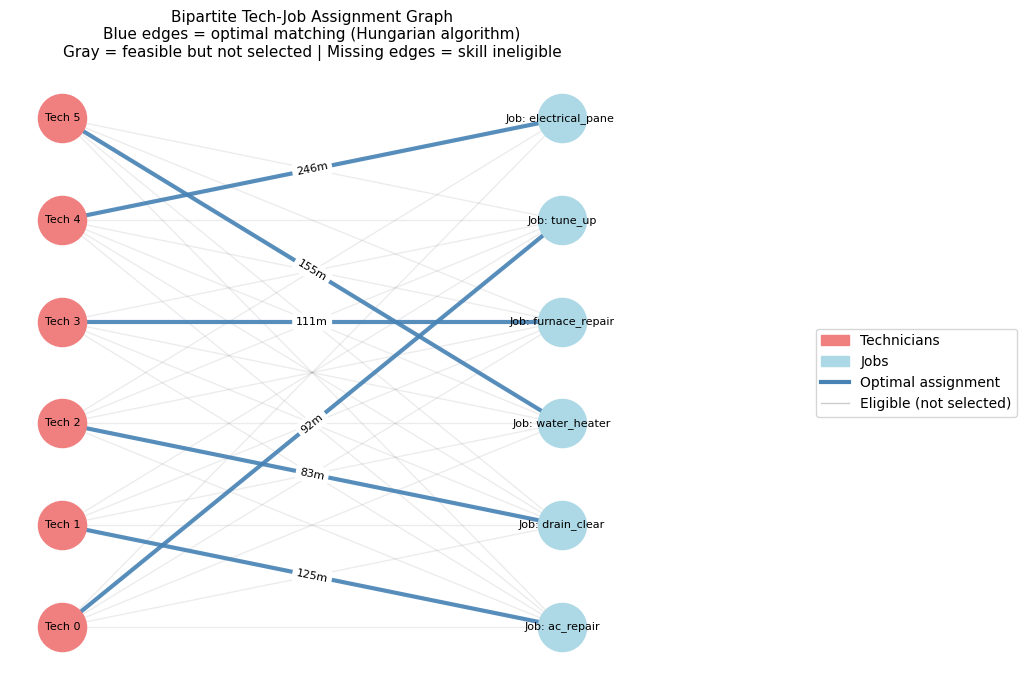

In [8]:
# --- Solve with Hungarian Algorithm ---
# linear_sum_assignment finds the minimum-cost perfect matching in O(n^3)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

print("\n=== Optimal Assignment (Hungarian Algorithm) ===")
total_cost = 0
assignments = []
for tech, job in zip(row_ind, col_ind):
    cost = cost_matrix[tech, job]
    assignments.append((tech, job, cost))
    flagged = " *** INFEASIBLE" if cost > 9000 else ""
    print(f"  Tech {tech}  ->  {job_types_sample[job]:>20}   cost: {cost:.0f} min{flagged}")
    total_cost += cost if cost < 9000 else 0
print(f"\nTotal feasible schedule cost: {total_cost:.0f} minutes")

# --- Build and visualize the bipartite graph ---
B = nx.Graph()
tech_nodes = [f"Tech {i}" for i in range(N_TECHS)]
job_nodes  = [f"Job: {j}" for j in job_types_sample]
B.add_nodes_from(tech_nodes, bipartite=0)
B.add_nodes_from(job_nodes,  bipartite=1)

for t in range(N_TECHS):
    for j in range(N_JOBS):
        if cost_matrix[t, j] < 9000:
            B.add_edge(tech_nodes[t], job_nodes[j], weight=cost_matrix[t, j])

pos = {}
for i, n in enumerate(tech_nodes):
    pos[n] = (0, i)
for i, n in enumerate(job_nodes):
    pos[n] = (3, i)

fig, ax = plt.subplots(figsize=(12, 7))

feasible_edges = [(u, v) for u, v, d in B.edges(data=True) if d['weight'] < 9000]
nx.draw_networkx_edges(B, pos, edgelist=feasible_edges, alpha=0.15,
                       edge_color='gray', width=1, ax=ax)

optimal_edges = [(tech_nodes[t], job_nodes[j]) for t, j, c in assignments if c < 9000]
nx.draw_networkx_edges(B, pos, edgelist=optimal_edges, alpha=0.9,
                       edge_color='steelblue', width=3, ax=ax)

edge_labels = {(tech_nodes[t], job_nodes[j]): f"{c:.0f}m"
               for t, j, c in assignments if c < 9000}
nx.draw_networkx_edge_labels(B, pos, edge_labels=edge_labels, font_size=8, ax=ax)

nx.draw_networkx_nodes(B, pos, nodelist=tech_nodes, node_color='lightcoral',
                       node_size=1200, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=job_nodes, node_color='lightblue',
                       node_size=1200, ax=ax)
nx.draw_networkx_labels(B, pos, font_size=8, ax=ax)

ax.set_title("Bipartite Tech-Job Assignment Graph\nBlue edges = optimal matching (Hungarian algorithm)\nGray = feasible but not selected | Missing edges = skill ineligible", fontsize=11)
ax.axis('off')

legend_elements = [
    mpatches.Patch(color='lightcoral', label='Technicians'),
    mpatches.Patch(color='lightblue', label='Jobs'),
    plt.Line2D([0],[0], color='steelblue', lw=3, label='Optimal assignment'),
    plt.Line2D([0],[0], color='gray', alpha=0.4, lw=1, label='Eligible (not selected)'),
]
ax.legend(handles=legend_elements, loc='center', bbox_to_anchor=(1.5, 0.5))
plt.tight_layout()
plt.savefig('dispatch_bipartite.png', dpi=100, bbox_inches='tight')
plt.show()


=== Route Optimization ===

Tech_A: 0 -> 7 -> 11 -> 3
  Total drive time: 123.2 min

Tech_B: 1 -> 5 -> 9 -> 13
  Total drive time: 90.5 min



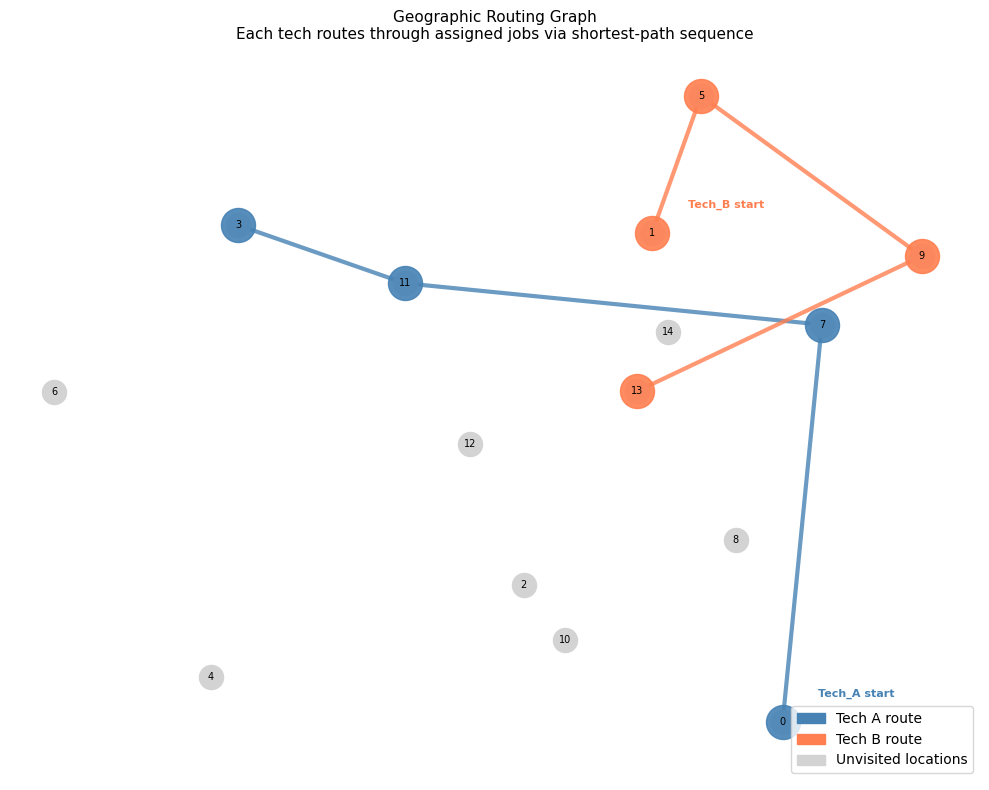

In [9]:
# --- Use Case 2: Geographic Routing Graph ---
# Model job locations and tech start positions as nodes in a weighted graph.
# Edge weight = estimated drive time. Find shortest route sequence per tech.
import networkx as nx

np.random.seed(10)
N_LOCATIONS = 15
locations = {i: (np.random.uniform(-20, 20), np.random.uniform(-20, 20))
             for i in range(N_LOCATIONS)}

G = nx.complete_graph(N_LOCATIONS)
SPEED_FACTOR = 2.5  # minutes per mile proxy
for u, v in G.edges():
    x1, y1 = locations[u]
    x2, y2 = locations[v]
    dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    G[u][v]['weight'] = round(dist * SPEED_FACTOR, 1)

tech_routes = {
    'Tech_A': {'start': 0, 'jobs': [3, 7, 11]},
    'Tech_B': {'start': 1, 'jobs': [5, 9, 13]},
}

def shortest_route(G, start, waypoints):
    # Nearest-neighbor heuristic (greedy TSP approximation)
    # For production: OR-Tools TSP solver
    remaining = list(waypoints)
    route = [start]
    current = start
    total_time = 0
    while remaining:
        nearest = min(remaining,
                      key=lambda n: nx.shortest_path_length(G, current, n, weight='weight'))
        travel = nx.shortest_path_length(G, current, nearest, weight='weight')
        route.append(nearest)
        total_time += travel
        remaining.remove(nearest)
        current = nearest
    return route, total_time

print("=== Route Optimization ===\n")
for tech, info in tech_routes.items():
    route, drive_time = shortest_route(G, info['start'], info['jobs'])
    print(f"{tech}: {' -> '.join(str(n) for n in route)}")
    print(f"  Total drive time: {drive_time:.1f} min\n")

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G, locations, node_size=300, node_color='lightgray', ax=ax)
nx.draw_networkx_labels(G, locations, font_size=7, ax=ax)

colors = {'Tech_A': 'steelblue', 'Tech_B': 'coral'}
for tech, info in tech_routes.items():
    route, _ = shortest_route(G, info['start'], info['jobs'])
    color = colors[tech]
    nx.draw_networkx_nodes(G, locations, nodelist=route,
                           node_color=color, node_size=600, alpha=0.9, ax=ax)
    route_edges = [(route[i], route[i+1]) for i in range(len(route)-1)]
    nx.draw_networkx_edges(G, locations, edgelist=route_edges,
                           edge_color=color, width=3, alpha=0.8, ax=ax,
                           arrows=True, arrowsize=20)
    start_pos = locations[info['start']]
    ax.annotate(f"{tech} start", xy=start_pos,
                xytext=(start_pos[0]+1.5, start_pos[1]+1.5),
                fontsize=8, color=color, fontweight='bold')

ax.set_title("Geographic Routing Graph\nEach tech routes through assigned jobs via shortest-path sequence", fontsize=11)
ax.axis('off')
legend_elements = [
    mpatches.Patch(color='steelblue', label='Tech A route'),
    mpatches.Patch(color='coral', label='Tech B route'),
    mpatches.Patch(color='lightgray', label='Unvisited locations'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('dispatch_routing.png', dpi=100, bbox_inches='tight')
plt.show()


### NetworkX Summary — When to Use It for Dispatch

| Problem | NetworkX Tool | Complexity | When to use |
|---|---|---|---|
| Assign N techs to N jobs | Bipartite matching / `linear_sum_assignment` | O(n^3) | Small daily batch (< ~100 techs) |
| Route sequence per tech | Shortest path / greedy TSP | O(n^2 log n) | Per-tech route optimization |
| Prune ineligible assignments | Subgraph filtering | O(V+E) | Pre-processing before optimizer |
| Detect coverage gaps | Connected components | O(V+E) | Zone planning, not real-time |

**Interview answer:** "I'd use NetworkX to prototype the structure — bipartite matching gives
optimal assignment for small N. In production at ServiceTitan's scale, you'd replace it with
OR-Tools VRP solver, but the graph abstraction and cost matrix construction are identical."


---
## Kafka / Azure Service Bus: Real-Time Dispatch Dataflow

Dispatch is inherently reactive — state changes constantly (job complete, new call,
cancellation, traffic incident). Polling a database is too slow and wastes DB load.
ServiceTitan uses **Azure Service Bus** (Kafka-compatible) to propagate state changes
as events that trigger ML inference and re-dispatch.

The diagram below shows the full event-driven pipeline from inbound call to tech notification.


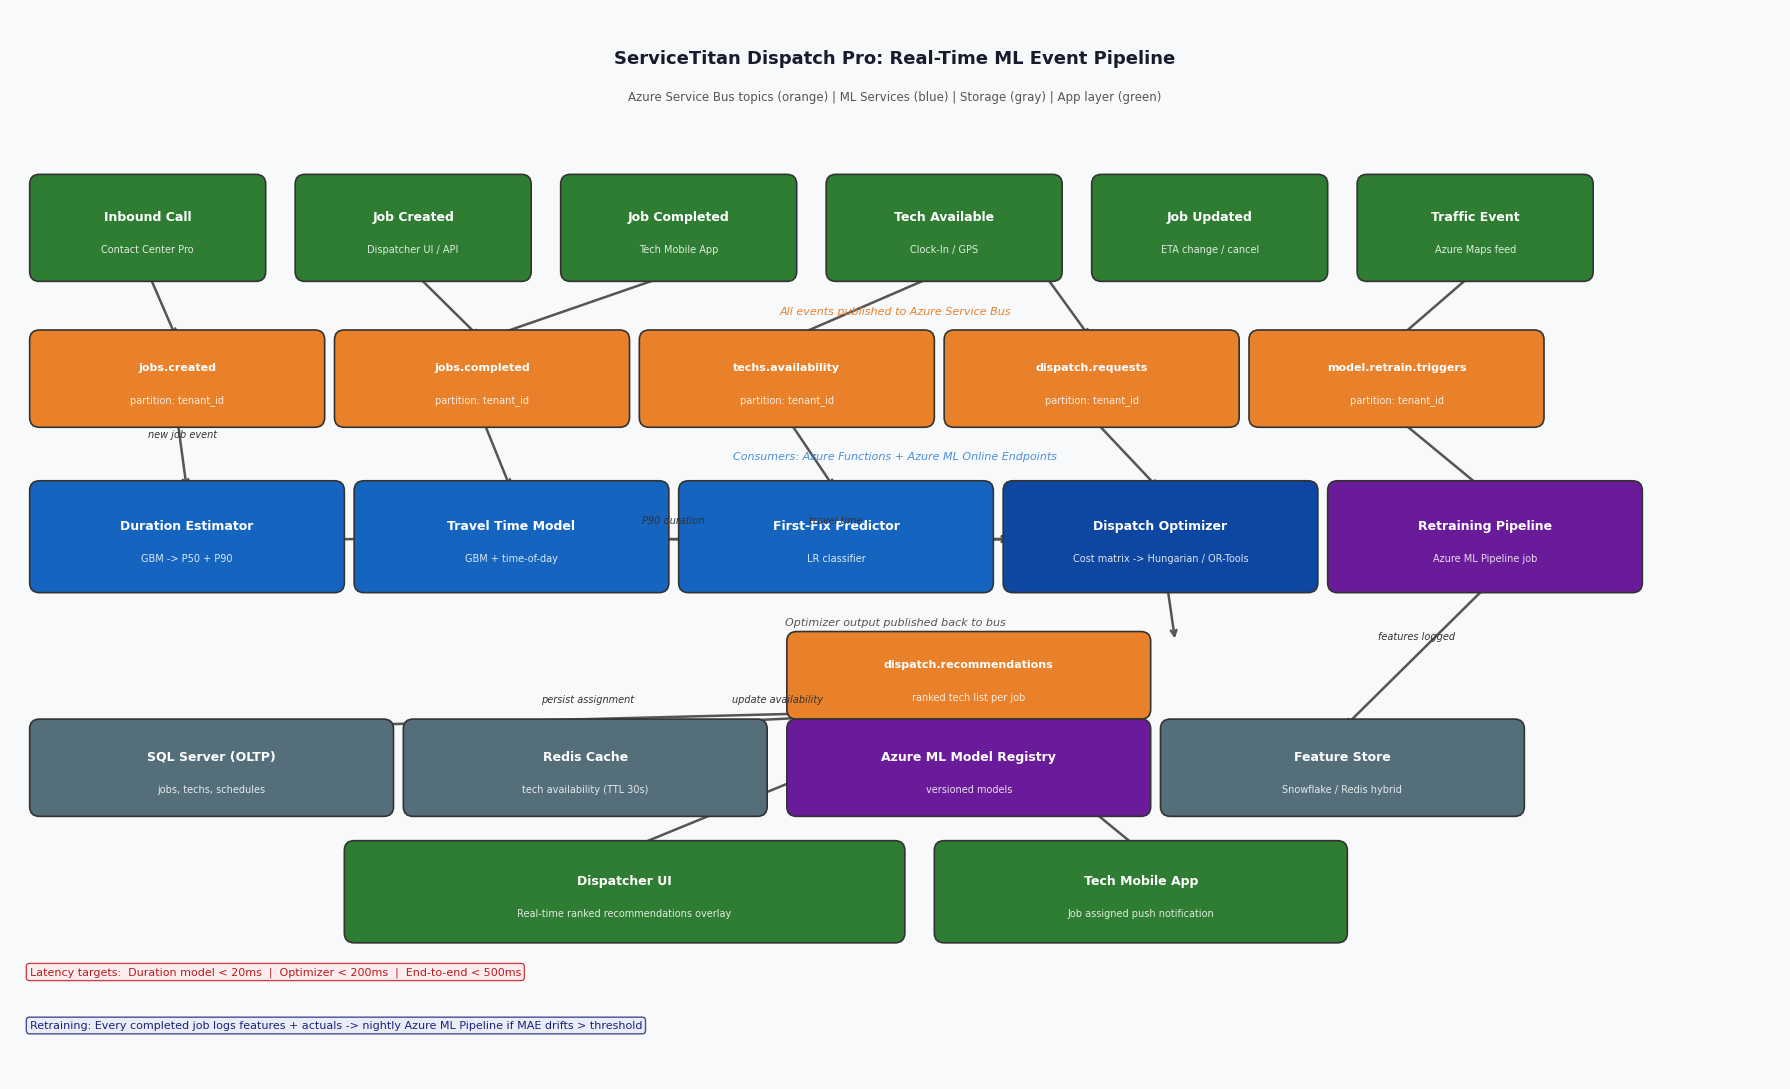

Kafka dataflow diagram saved.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

def draw_box(ax, x, y, w, h, label, sublabel="", color='#4a90d9', text_color='white', fontsize=9):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor='#333', linewidth=1.2, zorder=3)
    ax.add_patch(box)
    ax.text(x+w/2, y+h/2+(0.12 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize, color=text_color, fontweight='bold', zorder=4)
    if sublabel:
        ax.text(x+w/2, y+h/2-0.22, sublabel,
                ha='center', va='center', fontsize=7, color=text_color, alpha=0.85, zorder=4)

def arrow(ax, x1, y1, x2, y2, label="", color='#555'):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.15, label, ha='center', va='bottom', fontsize=7, color='#333', style='italic', zorder=5)

def kafka_topic(ax, x, y, w, h, label, sublabel=""):
    draw_box(ax, x, y, w, h, label, sublabel, color='#e8812a', text_color='white', fontsize=8)

ax.text(9, 10.5, "ServiceTitan Dispatch Pro: Real-Time ML Event Pipeline",
        ha='center', va='center', fontsize=13, fontweight='bold', color='#1a1a2e')
ax.text(9, 10.1, "Azure Service Bus topics (orange) | ML Services (blue) | Storage (gray) | App layer (green)",
        ha='center', va='center', fontsize=8.5, color='#555')

# Row 1: Event sources
draw_box(ax, 0.3, 8.3, 2.2, 0.9, "Inbound Call", "Contact Center Pro", color='#2e7d32')
draw_box(ax, 3.0, 8.3, 2.2, 0.9, "Job Created", "Dispatcher UI / API", color='#2e7d32')
draw_box(ax, 5.7, 8.3, 2.2, 0.9, "Job Completed", "Tech Mobile App", color='#2e7d32')
draw_box(ax, 8.4, 8.3, 2.2, 0.9, "Tech Available", "Clock-In / GPS", color='#2e7d32')
draw_box(ax, 11.1, 8.3, 2.2, 0.9, "Job Updated", "ETA change / cancel", color='#2e7d32')
draw_box(ax, 13.8, 8.3, 2.2, 0.9, "Traffic Event", "Azure Maps feed", color='#2e7d32')

ax.text(9, 7.9, "All events published to Azure Service Bus",
        ha='center', va='center', fontsize=8, color='#e8812a', style='italic')

# Row 2: Topics
kafka_topic(ax, 0.3,  6.8, 2.8, 0.8, "jobs.created", "partition: tenant_id")
kafka_topic(ax, 3.4,  6.8, 2.8, 0.8, "jobs.completed", "partition: tenant_id")
kafka_topic(ax, 6.5,  6.8, 2.8, 0.8, "techs.availability", "partition: tenant_id")
kafka_topic(ax, 9.6,  6.8, 2.8, 0.8, "dispatch.requests", "partition: tenant_id")
kafka_topic(ax, 12.7, 6.8, 2.8, 0.8, "model.retrain.triggers", "partition: tenant_id")

arrow(ax, 1.4, 8.3, 1.7, 7.6)
arrow(ax, 4.1, 8.3, 4.8, 7.6)
arrow(ax, 6.8, 8.3, 4.8, 7.6)
arrow(ax, 9.5, 8.3, 7.9, 7.6)
arrow(ax, 10.5, 8.3, 11.0, 7.6)
arrow(ax, 14.9, 8.3, 14.1, 7.6)

ax.text(9, 6.4, "Consumers: Azure Functions + Azure ML Online Endpoints",
        ha='center', va='center', fontsize=8, color='#4a90d9', style='italic')

# Row 3: ML services
draw_box(ax, 0.3, 5.1, 3.0, 0.95, "Duration Estimator", "GBM -> P50 + P90", color='#1565c0')
draw_box(ax, 3.6, 5.1, 3.0, 0.95, "Travel Time Model", "GBM + time-of-day", color='#1565c0')
draw_box(ax, 6.9, 5.1, 3.0, 0.95, "First-Fix Predictor", "LR classifier", color='#1565c0')
draw_box(ax, 10.2, 5.1, 3.0, 0.95, "Dispatch Optimizer", "Cost matrix -> Hungarian / OR-Tools", color='#0d47a1')
draw_box(ax, 13.5, 5.1, 3.0, 0.95, "Retraining Pipeline", "Azure ML Pipeline job", color='#6a1b9a')

arrow(ax, 1.7, 6.8, 1.8, 6.05, "new job event")
arrow(ax, 4.8, 6.8, 5.1, 6.05)
arrow(ax, 7.9, 6.8, 8.4, 6.05)
arrow(ax, 11.0, 6.8, 11.7, 6.05)
arrow(ax, 14.1, 6.8, 15.0, 6.05)
arrow(ax, 3.3, 5.55, 10.2, 5.55, "P90 duration")
arrow(ax, 6.6, 5.55, 10.2, 5.55, "travel time")
arrow(ax, 9.9, 5.55, 10.2, 5.55)

ax.text(9, 4.7, "Optimizer output published back to bus",
        ha='center', va='center', fontsize=8, color='#555', style='italic')

kafka_topic(ax, 8.0, 3.8, 3.5, 0.7, "dispatch.recommendations", "ranked tech list per job")
arrow(ax, 11.7, 5.55, 11.85, 4.5)

# Row 4: Storage
draw_box(ax, 0.3,  2.8, 3.5, 0.8, "SQL Server (OLTP)", "jobs, techs, schedules", color='#546e7a')
draw_box(ax, 4.1,  2.8, 3.5, 0.8, "Redis Cache", "tech availability (TTL 30s)", color='#546e7a')
draw_box(ax, 8.0,  2.8, 3.5, 0.8, "Azure ML Model Registry", "versioned models", color='#6a1b9a')
draw_box(ax, 11.8, 2.8, 3.5, 0.8, "Feature Store", "Snowflake / Redis hybrid", color='#546e7a')

arrow(ax, 9.75, 3.8, 9.75, 3.6)
arrow(ax, 9.75, 3.8, 2.0, 3.6, "persist assignment")
arrow(ax, 9.75, 3.8, 5.85, 3.6, "update availability")
arrow(ax, 15.05, 5.1, 13.55, 3.6, "features logged")

# Row 5: App layer
draw_box(ax, 3.5, 1.5, 5.5, 0.85, "Dispatcher UI", "Real-time ranked recommendations overlay", color='#2e7d32')
draw_box(ax, 9.5, 1.5, 4.0, 0.85, "Tech Mobile App", "Job assigned push notification", color='#2e7d32')
arrow(ax, 9.75, 3.8, 6.25, 2.35)
arrow(ax, 9.75, 3.8, 11.5, 2.35)

ax.text(0.2, 1.1,
        "Latency targets:  Duration model < 20ms  |  Optimizer < 200ms  |  End-to-end < 500ms",
        ha='left', va='center', fontsize=8, color='#b71c1c',
        bbox=dict(boxstyle='round', facecolor='#ffebee', edgecolor='#b71c1c', alpha=0.8))
ax.text(0.2, 0.55,
        "Retraining: Every completed job logs features + actuals -> nightly Azure ML Pipeline if MAE drifts > threshold",
        ha='left', va='center', fontsize=8, color='#1a237e',
        bbox=dict(boxstyle='round', facecolor='#e8eaf6', edgecolor='#1a237e', alpha=0.8))

plt.tight_layout()
plt.savefig('dispatch_kafka_dataflow.png', dpi=120, bbox_inches='tight')
plt.show()
print("Kafka dataflow diagram saved.")


---
## How the Model Is Deployed: Azure ML Online Endpoint

**Key deployment decisions:**

| Decision | Choice | Why |
|---|---|---|
| Serving | Azure ML Online Endpoint (managed) | Auto-scaling, blue/green deployment, monitoring built in |
| Format | ONNX (exported from sklearn) | 3-5x inference speedup vs native sklearn predict() |
| Batching | Mini-batch (8-16 jobs per request) | Optimizer needs all techs' estimates simultaneously |
| Caching | Redis (TTL 60s) | Same job re-estimated as techs become available |
| Feature store | Azure ML Feature Store / Redis | Pre-computed tech speed history served sub-1ms |
| Monitoring | Azure ML data drift detection | Alert if feature distributions shift (e.g. new job type) |

### The scoring script (what runs inside the endpoint container)


In [11]:
import json, time
import numpy as np
import pandas as pd

# This simulates the Azure ML scoring script (score.py inside the endpoint container).
# In deployment: init() runs once at container startup, run() handles each HTTP POST.

class DispatchInferenceService:
    # Simulates what runs inside an Azure ML Online Endpoint container.
    # init() -> called once at startup, loads model from AZUREML_MODEL_DIR
    # run()  -> called per request, does feature validation + inference

    def __init__(self, preprocessor, model_p50, model_p90):
        self.preprocessor = preprocessor
        self.model_p50 = model_p50
        self.model_p90 = model_p90
        self.required_fields = [
            'job_type', 'equipment_age_yrs', 'property_sqft',
            'new_customer', 'tech_id', 'time_of_day', 'day_of_week'
        ]
        self.valid_job_types = {
            'ac_repair', 'ac_install', 'furnace_repair', 'furnace_install',
            'drain_clear', 'water_heater', 'electrical_panel', 'tune_up'
        }
        print("[init] Model loaded. Endpoint ready.")

    def _validate(self, records):
        for i, rec in enumerate(records):
            missing = [f for f in self.required_fields if f not in rec]
            if missing:
                raise ValueError(f"Record {i} missing fields: {missing}")
            if rec['job_type'] not in self.valid_job_types:
                raise ValueError(f"Unknown job_type: {rec['job_type']}")
        return True

    def run(self, raw_data: str) -> str:
        # Entry point for each inference request.
        # Input:  JSON string with list of job records
        # Output: JSON string with P50, P90, uncertainty band per record
        t0 = time.perf_counter()
        data = json.loads(raw_data)
        records = data.get('jobs', [])
        if not records:
            return json.dumps({'error': 'No jobs in request', 'predictions': []})
        self._validate(records)
        df = pd.DataFrame(records)[self.required_fields]
        X_transformed = self.preprocessor.transform(df)
        p50_preds = self.model_p50.predict(X_transformed)
        p90_preds = self.model_p90.predict(X_transformed)
        latency_ms = (time.perf_counter() - t0) * 1000
        predictions = []
        for i, rec in enumerate(records):
            predictions.append({
                'job_index':        i,
                'job_type':         rec['job_type'],
                'tech_id':          rec['tech_id'],
                'p50_duration_min': round(float(p50_preds[i]), 1),
                'p90_duration_min': round(float(p90_preds[i]), 1),
                'uncertainty_band': round(float(p90_preds[i] - p50_preds[i]), 1),
                'schedule_with':    round(float(p90_preds[i]), 1),  # optimizer uses P90
            })
        return json.dumps({
            'predictions':   predictions,
            'latency_ms':    round(latency_ms, 2),
            'model_version': '2.1.0',
        })

# Test the service (preprocessor and models were trained in earlier cells)
service = DispatchInferenceService(preprocessor, model_p50, model_p90)

request_payload = json.dumps({'jobs': [
    {'job_type': 'ac_repair', 'equipment_age_yrs': 12, 'property_sqft': 2100,
     'new_customer': 1, 'tech_id': 3, 'time_of_day': 'morning', 'day_of_week': 'Mon'},
    {'job_type': 'drain_clear', 'equipment_age_yrs': 5, 'property_sqft': 1600,
     'new_customer': 0, 'tech_id': 7, 'time_of_day': 'midday', 'day_of_week': 'Wed'},
    {'job_type': 'electrical_panel', 'equipment_age_yrs': 18, 'property_sqft': 2800,
     'new_customer': 0, 'tech_id': 1, 'time_of_day': 'afternoon', 'day_of_week': 'Fri'},
]})

response = json.loads(service.run(request_payload))
print(f"Inference latency: {response['latency_ms']:.2f} ms")
print(f"Model version:     {response['model_version']}\n")
print(f"{'Job Type':>22}  {'Tech':>6}  {'P50':>6}  {'P90':>6}  {'Uncertainty':>12}  {'Schedule With':>14}")
print("-" * 80)
for pred in response['predictions']:
    print(f"{pred['job_type']:>22}  {pred['tech_id']:>6}  "
          f"{pred['p50_duration_min']:>6.1f}  {pred['p90_duration_min']:>6.1f}  "
          f"{pred['uncertainty_band']:>12.1f}  {pred['schedule_with']:>14.1f}")


[init] Model loaded. Endpoint ready.
Inference latency: 8.69 ms
Model version:     2.1.0

              Job Type    Tech     P50     P90   Uncertainty   Schedule With
--------------------------------------------------------------------------------
             ac_repair       3   123.4   126.9           3.5           126.9
           drain_clear       7    47.8    55.2           7.4            55.2
      electrical_panel       1   235.0   275.9          40.9           275.9


In [12]:
deployment_config = {
    "endpoint_name": "dispatch-duration-estimator",
    "deployment": {
        "name": "blue",
        "model": "dispatch_duration_model:2.1.0",
        "environment": "dispatch-inference-env:3",
        "code_configuration": {"code": "./score/", "scoring_script": "score.py"},
        "instance_type": "Standard_DS2_v2",   # 2 vCPU, 7 GB RAM
        "instance_count": 2,
        "scale_settings": {
            "type": "auto",
            "min_instances": 2,
            "max_instances": 10,
            "polling_interval": 5,
            "target_utilization_percentage": 70
        },
        "request_settings": {
            "request_timeout_ms": 500,
            "max_concurrent_requests_per_instance": 20
        },
    },
    "traffic": {"blue": 100}
}

print("Azure ML Endpoint Configuration:")
print("=" * 55)
d = deployment_config['deployment']
print(f"  Endpoint:        {deployment_config['endpoint_name']}")
print(f"  Model:           {d['model']}")
print(f"  Instance type:   {d['instance_type']}")
scale = d['scale_settings']
print(f"  Auto-scale:      {scale['min_instances']}-{scale['max_instances']} instances")
print(f"  Scale trigger:   {scale['target_utilization_percentage']}% CPU utilization")
print(f"  Request timeout: {d['request_settings']['request_timeout_ms']} ms")
print()
print("Deployment strategy: Blue/Green")
print("  -> New model version deploys to 'green' slot")
print("  -> 10% traffic shifted to green (canary)")
print("  -> Monitor MAE on live traffic for 24h")
print("  -> If no drift: traffic['green'] = 100, retire blue")
print()
print("Retraining trigger:")
print("  -> Azure ML Pipeline runs nightly")
print("  -> Input: last 30 days completed jobs (actual vs predicted duration)")
print("  -> If MAE on holdout > 10% above baseline: auto-deploy new version")
print("  -> Alert to MLOps Slack channel if retraining fails or model degrades")


Azure ML Endpoint Configuration:
  Endpoint:        dispatch-duration-estimator
  Model:           dispatch_duration_model:2.1.0
  Instance type:   Standard_DS2_v2
  Auto-scale:      2-10 instances
  Scale trigger:   70% CPU utilization
  Request timeout: 500 ms

Deployment strategy: Blue/Green
  -> New model version deploys to 'green' slot
  -> 10% traffic shifted to green (canary)
  -> Monitor MAE on live traffic for 24h
  -> If no drift: traffic['green'] = 100, retire blue

Retraining trigger:
  -> Azure ML Pipeline runs nightly
  -> Input: last 30 days completed jobs (actual vs predicted duration)
  -> If MAE on holdout > 10% above baseline: auto-deploy new version
  -> Alert to MLOps Slack channel if retraining fails or model degrades


---
## Key Takeaways (Updated)

### ML Architecture
1. **ML provides inputs; the optimizer makes assignments** — duration + travel time models feed a cost matrix solved by Hungarian algorithm (small N) or OR-Tools VRPTW (production scale)
2. **Use P90 duration estimates for scheduling** — P50 means half your afternoon cascades; P90 absorbs most real-world overruns
3. **Technician ID is a valid, important feature** — speed variance between techs is real and measurable

### Graph Structure (NetworkX)
4. **Dispatch is fundamentally a min-weight bipartite matching problem** — NetworkX + `linear_sum_assignment` gives optimal solution for small instances
5. **Geographic routing = weighted graph shortest path** — nearest-neighbor heuristic for fast route sequencing; OR-Tools TSP for production

### Real-Time Architecture
6. **Event-driven via Azure Service Bus** — every job state change is an event that triggers ML inference; no polling
7. **Latency budget**: Duration model < 20ms | Full optimizer < 200ms | End-to-end < 500ms
8. **Multi-tenant partitioning**: Topics partitioned by `tenant_id` — data isolation + parallel processing

### Deployment
9. **Azure ML Online Endpoint** with ONNX export for speed; blue/green canary deployments
10. **Feedback loop**: Every completed job logs `(features, actual_duration)` -> nightly retraining pipeline -> auto-deploy if MAE improves
